In [1]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [2]:
!mkdir -p ~/.kaggle
!cp "kaggle.json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d andrewmvd/drive-digital-retinal-images-for-vessel-extraction


Dataset URL: https://www.kaggle.com/datasets/andrewmvd/drive-digital-retinal-images-for-vessel-extraction
License(s): other
  0% 0.00/28.0M [00:00<?, ?B/s]
100% 28.0M/28.0M [00:00<00:00, 1.04GB/s]


In [4]:
!unzip drive-digital-retinal-images-for-vessel-extraction.zip


Archive:  drive-digital-retinal-images-for-vessel-extraction.zip
  inflating: DRIVE/test/images/01_test.tif  
  inflating: DRIVE/test/images/02_test.tif  
  inflating: DRIVE/test/images/03_test.tif  
  inflating: DRIVE/test/images/04_test.tif  
  inflating: DRIVE/test/images/05_test.tif  
  inflating: DRIVE/test/images/06_test.tif  
  inflating: DRIVE/test/images/07_test.tif  
  inflating: DRIVE/test/images/08_test.tif  
  inflating: DRIVE/test/images/09_test.tif  
  inflating: DRIVE/test/images/10_test.tif  
  inflating: DRIVE/test/images/11_test.tif  
  inflating: DRIVE/test/images/12_test.tif  
  inflating: DRIVE/test/images/13_test.tif  
  inflating: DRIVE/test/images/14_test.tif  
  inflating: DRIVE/test/images/15_test.tif  
  inflating: DRIVE/test/images/16_test.tif  
  inflating: DRIVE/test/images/17_test.tif  
  inflating: DRIVE/test/images/18_test.tif  
  inflating: DRIVE/test/images/19_test.tif  
  inflating: DRIVE/test/images/20_test.tif  
  inflating: DRIVE/test/mask/01_tes

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_niblack, threshold_sauvola


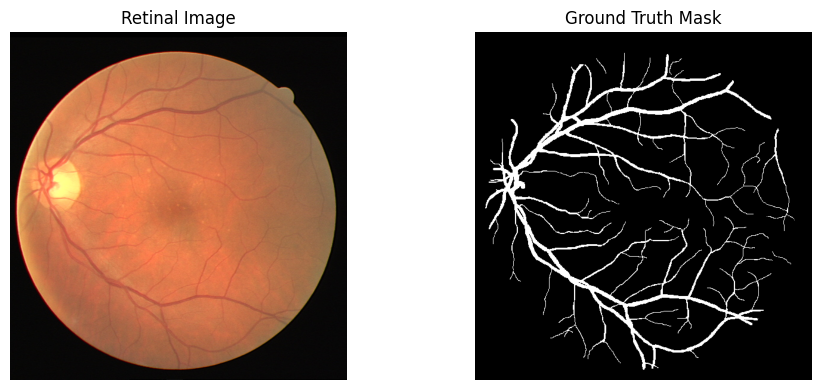

In [8]:
import os
import cv2
import matplotlib.pyplot as plt

# Base dataset path (already downloaded)
base_dir = "DRIVE"

img_id = "21"

# Build paths
retina_file = os.path.join(base_dir, "training", "images", f"{img_id}_training.tif")
gt_file = os.path.join(base_dir, "training", "1st_manual", f"{img_id}_manual1.gif")

# Read images
retina_img = cv2.cvtColor(cv2.imread(retina_file), cv2.COLOR_BGR2RGB)
gt_img = cv2.imread(gt_file, 0)

# Display
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(retina_img)
plt.title("Retinal Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(gt_img, cmap="gray")
plt.title("Ground Truth Mask")
plt.axis("off")

plt.tight_layout()
plt.show()

In [14]:
import numpy as np

vessel_pixels = np.sum(gt_img > 0)
background_pixels = np.sum(gt_img == 0)

In [13]:
def compute_sensitivity(pred, gt):

    TP = np.sum((pred == 1) & (gt == 1))


    FN = np.sum((pred == 0) & (gt == 1))

    sensitivity = TP / (TP + FN + 1e-8)

    return sensitivity


In [15]:

train_img_dir = "DRIVE/training/images"
train_gt_dir = "DRIVE/training/1st_manual"
train_mask_dir = "DRIVE/training/mask"
image_list = sorted(os.listdir(train_img_dir))
niblack_sens = []
sauvola_sens = []

In [17]:
for img_name in image_list:

    img_path = os.path.join(train_img_dir, img_name)
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)


    number = img_name.split("_")[0]


    gt_path = os.path.join(train_gt_dir, number + "_manual1.gif")
    gt = cv2.imread(gt_path, 0)
    gt_binary = gt > 0


    mask_path = os.path.join(train_mask_dir, number + "_training_mask.gif")
    fov = cv2.imread(mask_path, 0)
    fov_binary = fov > 0

    green = image[:, :, 1]
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(green)

    thresh_n = threshold_niblack(enhanced, window_size=25, k=-0.2)
    binary_niblack = enhanced < thresh_n
    binary_niblack = binary_niblack & fov_binary


    thresh_s = threshold_sauvola(enhanced, window_size=25, k=0.5)
    binary_sauvola = enhanced < thresh_s
    binary_sauvola = binary_sauvola & fov_binary


    gt_binary = gt_binary & fov_binary
    sens_n = compute_sensitivity(binary_niblack, gt_binary)
    sens_s = compute_sensitivity(binary_sauvola, gt_binary)


    niblack_sens.append(sens_n)
    sauvola_sens.append(sens_s)

In [19]:
print("NIBLACK-")
print("Average Sensitivity:", np.mean(niblack_sens))

print("\nSAUVOLA-")
print("Average Sensitivity:", np.mean(sauvola_sens))

NIBLACK-
Average Sensitivity: 0.9083322896039553

SAUVOLA-
Average Sensitivity: 0.14058519582354614


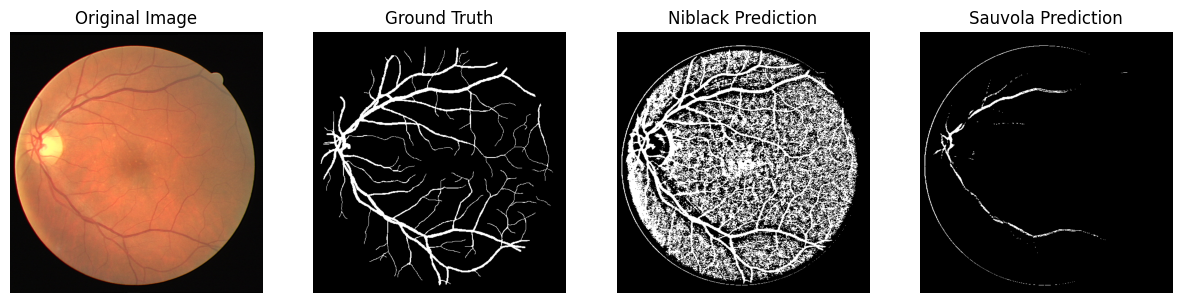

In [20]:
import matplotlib.pyplot as plt


sample_img_name = image_list[0]  # first image
img_path = os.path.join(train_img_dir, sample_img_name)
image = cv2.imread(img_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

number = sample_img_name.split("_")[0]


gt_path = os.path.join(train_gt_dir, number + "_manual1.gif")
gt = cv2.imread(gt_path, 0)
gt_binary = gt > 0

mask_path = os.path.join(train_mask_dir, number + "_training_mask.gif")
fov = cv2.imread(mask_path, 0)
fov_binary = fov > 0


green = image[:, :, 1]
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
enhanced = clahe.apply(green)


thresh_n = threshold_niblack(enhanced, window_size=25, k=-0.2)
binary_niblack = enhanced < thresh_n
binary_niblack = binary_niblack & fov_binary

thresh_s = threshold_sauvola(enhanced, window_size=25, k=0.5)
binary_sauvola = enhanced < thresh_s
binary_sauvola = binary_sauvola & fov_binary


plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,4,2)
plt.imshow(gt_binary, cmap='gray')
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,4,3)
plt.imshow(binary_niblack, cmap='gray')
plt.title("Niblack Prediction")
plt.axis("off")

plt.subplot(1,4,4)
plt.imshow(binary_sauvola, cmap='gray')
plt.title("Sauvola Prediction")
plt.axis("off")

plt.show()
